# 4	Development and Validation of an Integrated Prediction Model

### 4.0 seperate the dataset into modeling dataset and the independent testing dataset

In [48]:
# to establish a independent dataset, we will extract the data point in the dataset (20240518final_merge_data_with_high_1433pre_mapped_to_human.csv) but not 14-3-3 pred and 14-3-3 finder dataset
import pandas as pd
pred_dataset_name = 'data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx'
finder_dataset_name = "data/NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx"
curated_dataset_name = "data/20240518final_merge_data_with_high_1433pre_mapped_to_human.csv"

In [49]:
# the data in data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx have 4 tab, combine them into one
file_path = pred_dataset_name
excel_file = pd.ExcelFile(file_path)

# Let's get the sheet names
sheet_names = excel_file.sheet_names

# Create an empty list to hold dataframes
dfs = []

# Loop through the sheet names and read each sheet into a dataframe
for sheet in sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    # Optionally, you can add a column indicating the sheet name, useful for tracking the data source
    df['Source_Sheet'] = sheet
    dfs.append(df)

# Concatenate all the dataframes
pred_dataset_df = pd.concat(dfs, ignore_index=True)
pred_dataset_df = pred_dataset_df[pred_dataset_df['PMID'] != '*Likely NEG sites ']
pred_dataset_df = pred_dataset_df[["Uniprot ID","Site","Residue"]]
pred_dataset_df["Site"] = pred_dataset_df["Site"].astype(int)
pred_dataset_df.head(2)

/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Uniprot ID,Site,Residue
0,P78314,225,S
1,P78314,278,S


In [50]:
# 14-3-3 finder dataset preprocess
finder_dataset_df = pd.read_excel(finder_dataset_name)
finder_dataset_df = finder_dataset_df[["Uniprot ID", 'Site',"Residue"]]
finder_dataset_df.head(2)

,Uniprot ID,Site,Residue
0,A7KAX9,1796,S
1,O00159,736,S


In [51]:
import re
previous_datset_df = pd.concat([pred_dataset_df, finder_dataset_df], ignore_index=True)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(str)

# Define the replacement function
def replace_value(value):
    matches = re.findall(r'\(([^)]+)\)', value)    
    if matches:
        return matches[0]  # Replace with the number within parentheses
    else:
        return value


# Apply the function to the 'Site' column
previous_datset_df['Site'] = previous_datset_df['Site'].apply(replace_value)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(int)

# remove duplicates
previous_datset_df = previous_datset_df.drop_duplicates(subset=["Uniprot ID", "Site"], keep='first')

previous_datset_df["uniqueID"] = (
    previous_datset_df["Uniprot ID"].str.strip() + "_" +
    previous_datset_df["Residue"].str.strip().str.upper() +
    previous_datset_df["Site"].astype(str).str.strip() +
    previous_datset_df["Residue"].str.strip().str.lower()
)

# put the uniqueID into a set
uniqueid_dict = set(previous_datset_df["uniqueID"])

has_duplicates = previous_datset_df["uniqueID"].duplicated().any()
print(f"Are there duplicates in column uniqueID? {has_duplicates}")

Are there duplicates in column uniqueID? False


In [52]:
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df["uniqueID"] = (
    curated_dataset_df["human homology accession"].str.strip() + "_" +
    curated_dataset_df['human Site and Mutation'].str.strip()
)

independent_dataset_df = curated_dataset_df[~curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
independent_dataset_df["label"].value_counts()

label
0    181
1    179
Name: count, dtype: int64

In [53]:
used_dataset_df =  curated_dataset_df[curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
used_dataset_df["label"].value_counts()

label
0    308
1    277
Name: count, dtype: int64

In [54]:
# we have too much independent data here, some of the independent data will also be used for training.

In [55]:
# check how many of the independent data are come from the mutation of a positive site sample
# those data should be exclude from the training dataset to avoid overfitting
# add more previous not see protein in the training dataset
# independent_dataset_df[independent_dataset_df['uniqueID'].str.contains('/')].head(2)

In [56]:
# augmentated the data first, 
# for the positive/negative data, makesure the protein and corresponding augmentated proteins are either all in the training or all in the independent dataset
# make sure the training and independent datasets all follow the same distribution
# set 10% data as independent dataset

### 4.1	Positive data augmentation strategy: 

task 31: By analysis the 14-3-3 protein homology in evolution tree, we found that 14-3-3 is quite conservative until XX animal (Figure X). 

In [57]:
# download all Vertebrata 14-3-3 protein homology 

In [58]:
import pandas as pd
import os
def process_txt_file(file_path) -> pd.DataFrame:
    with open(os.path.join(".","data", "blast1433_results", "summary",file_path), 'r') as file:
        all_datas = []
        for line in file:
            line_data = line.strip().strip('()').split(', ')
            # print(line_data)
            all_datas.append(line_data)
        df = pd.DataFrame(all_datas, columns=['1433uniprot_id', "taxonomic_id", "e_value", "identity length", "alignment length"])
    return df

In [59]:
# Get all files in the directory
files = os.listdir(os.path.join(".","data","blast1433_results", "summary"))
merged_df = None

# Display the file names
for file_name in files:
    # print(file_name)
    df = process_txt_file(file_name)
    if merged_df is None:
        merged_df = df
    else:
        merged_df = pd.concat([merged_df, df])

In [60]:
protein_length={"'P27348'": 245, "'P31946'":246, "'P31947'": 248, "'P61981'": 247, "'P62258'": 255, "'P63104'":245,  "'Q04917'": 246}

merged_df["protein_length"] = 0  # Initialize the new column with zeros
# Iterate through the DataFrame rows
for index, row in merged_df.iterrows():
    # # Perform computations or conditions based on row values and assign to the new column 'C'
    # ratio = int(row["identity length"])/protein_length[row["1433uniprot_id"]]
    # print(ratio)
    # new_merged_df.loc[index, "alignment_rate"] = ratio  # For example, multiplying columns 'A' and 'B'
    merged_df.loc[index, "protein_length"] = protein_length[row["1433uniprot_id"]]

In [61]:
merged_df["alignment pair"] = merged_df["1433uniprot_id"]+'_'+merged_df["taxonomic_id"]
merged_df["identity length"]= merged_df["identity length"].astype(int)
merged_df['alignment_rate'] = merged_df["identity length"]/merged_df["protein_length"]
merged_df['taxonomic_id'] = merged_df['taxonomic_id'].astype(str)
merged_df['alignment_rate'] = pd.to_numeric(merged_df['alignment_rate'], errors='coerce')
merged_df['1433uniprot_id'] = merged_df['1433uniprot_id'].astype(str)
merged_df = merged_df.reset_index(drop=True)

In [62]:
merged_df.head(2)

,1433uniprot_id,taxonomic_id,e_value,identity length,alignment length,protein_length,alignment pair,alignment_rate
0,'P27348',8839,0.0,242,245,245,'P27348'_8839,0.987755
1,'P31946',8839,3.70784e-179,239,302,246,'P31946'_8839,0.971545


In [63]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   1433uniprot_id    343 non-null    object 
 1   taxonomic_id      343 non-null    object 
 2   e_value           343 non-null    object 
 3   identity length   343 non-null    int64  
 4   alignment length  343 non-null    object 
 5   protein_length    343 non-null    int64  
 6   alignment pair    343 non-null    object 
 7   alignment_rate    343 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 21.6+ KB


In [64]:
print(merged_df.isnull().sum())

1433uniprot_id      0
taxonomic_id        0
e_value             0
identity length     0
alignment length    0
protein_length      0
alignment pair      0
alignment_rate      0
dtype: int64


In [65]:
merged_df.head(2)

,1433uniprot_id,taxonomic_id,e_value,identity length,alignment length,protein_length,alignment pair,alignment_rate
0,'P27348',8839,0.0,242,245,245,'P27348'_8839,0.987755
1,'P31946',8839,3.70784e-179,239,302,246,'P31946'_8839,0.971545


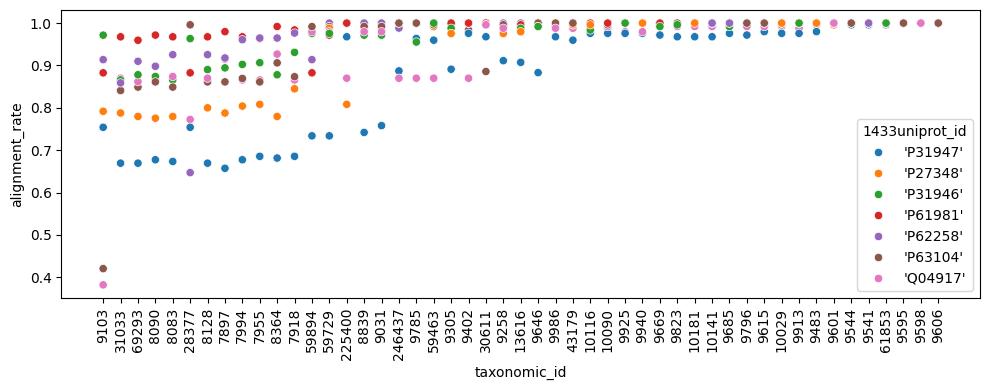

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate mean alignment rate for each taxonomic_id and sort
avg_by_taxid = merged_df.groupby('taxonomic_id')['alignment_rate'].mean().sort_values()
sorted_taxids = avg_by_taxid.index

# Create a new dataframe with sorted taxonomic_ids
merged_df_sorted = merged_df.copy()
merged_df_sorted['taxonomic_id'] = pd.Categorical(merged_df_sorted['taxonomic_id'], 
                                                categories=sorted_taxids, 
                                                ordered=True)
merged_df_sorted = merged_df_sorted.sort_values('taxonomic_id')

# Create the plot
plt.figure(figsize=(10, 4))
sns.scatterplot(data=merged_df_sorted, 
                x='taxonomic_id', 
                y='alignment_rate', 
                hue='1433uniprot_id')

plt.xticks(rotation=90, fontsize=10)
plt.xlabel('taxonomic_id')
plt.ylabel('alignment_rate')
plt.title('')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

In [67]:
merged_df_sorted.head(2)

,1433uniprot_id,taxonomic_id,e_value,identity length,alignment length,protein_length,alignment pair,alignment_rate
247,'P31947',9103,8.85145e-135,187,246,248,'P31947'_9103,0.754032
245,'P27348',9103,2.3004e-148,194,245,245,'P27348'_9103,0.791837


In [68]:
# drop 9103
sampling_species_lst = set(merged_df_sorted["taxonomic_id"])
sampling_species_lst.remove("9103")

In [69]:
len(sampling_species_lst)

48

In [70]:
# sampling_species_lst

task 32: Utilizing this approach, we selected 5 different species (XX,XX) where the 14-3-3 protein sequences are conserved. To ensure adequate diversity, we also included different isoforms from these species. (sampling from uniref90?, then make sure by MSA, the sequence have a similary 14-3-3 sites)

In [71]:
# 原始数据中有的蛋白上有5-1个位点，增强的数据应该把同源蛋白的数量填充到最多五个， 比如如果某个蛋白上有2个位点，那么我们只增强三个位点，使总蛋白数是5
# 选1.uniref_90 2. aligment 3. at the positive have the same motif （比如 rxxs or rxxt） 4.blast similary 大致相同， 5. 在特定的种群列表里面 6。 距离最远的4个, # 增强的数据位点，在用以前的predictor测试一下，保证增强数据在他们的短距离的predictor中是推荐的位点

In [72]:
### Download all homologous sequences for a given protein UniProt ID within a specified list of species.

In [73]:
# install Blast+
# https://blast.ncbi.nlm.nih.gov/doc/blast-help/downloadblastdata.html#downloadblastdata

In [74]:
# https://ftp.uniprot.org/pub/databases/uniprot/current_release/uniref/uniref90/
# download uniref90
# build db uniref90 for blast search and retrieve

In [75]:
# filter_fasta_by_taxid
# from Bio import SeqIO

# # Define the list of TaxIDs you want to filter by
# taxid_list = sampling_species_lst 

# # Input and output FASTA file paths
# input_fasta = "../Downloads/uniref90.fasta"
# output_fasta = "data/filtered_uniref90.fasta"

# def filter_fasta_by_taxid(input_fasta, output_fasta, taxid_list):
#     count_no_taxid = 0  # Counter for records without TaxID info
#     count_invalid_taxid = 0  # Counter for records with invalid TaxID info

#     with open(output_fasta, "w") as out_file:
#         for record in SeqIO.parse(input_fasta, "fasta"):
#             header = record.description
#             parts = header.split('TaxID=')
#             if len(parts) > 1:
#                 taxid_part = parts[1]
#                 taxid_split = taxid_part.split()
#                 if taxid_split:
#                     try:
#                         taxid = str(taxid_split[0])
#                         if taxid in taxid_list:
#                             SeqIO.write(record, out_file, "fasta")
#                     except ValueError:
#                         count_invalid_taxid += 1
#                 else:
#                     count_no_taxid += 1
#             else:
#                 count_no_taxid += 1

#     # Report the count of records without TaxID information
#     print(f"Number of records without TaxID information: {count_no_taxid}")
#     print(f"Number of records with invalid TaxID information: {count_invalid_taxid}")

# # Run the filtering function
# filter_fasta_by_taxid(input_fasta, output_fasta, taxid_list)

In [76]:
# build db uniref90-48 for blast search and retrieve

In [77]:
# build db human-reviewed for blast search and retrieve

In [78]:
import os
import requests
from Bio.Blast.Applications import NcbiblastpCommandline
from Bio.Blast import NCBIXML
import re
def perform_blast_human(sequence, db, target_species, output_file='blast_result_human.xml'):
    """Perform a BLAST search using local BLAST and return the best hit for the target species."""
    with open("query_human.fasta", "w") as f:
        f.write(sequence)
    
    # Specify the full path to the blastp executable
    blastp_path = "/Users/newuser/ncbi-blast-2.16.0+/bin/blastp" 

    blastp_cline = NcbiblastpCommandline(cmd=blastp_path, query="query_human.fasta", db=db, evalue=0.001, outfmt=5, out=output_file)
    
    # Run BLASTP and capture stdout and stderr
    stdout, stderr = blastp_cline()
    
    with open(output_file) as result_handle:
        blast_records = NCBIXML.read(result_handle)
    
    for alignment in blast_records.alignments:
        hit_id = alignment.hit_id
        hit_def = alignment.hit_def
        # print(f"Checking hit {hit_id}: {hit_def}")  # Debug output
        uniprot_id, species = get_species_uniprot_id_human(hit_def)
        if species == target_species:
            return alignment
    
    return None

def get_species_uniprot_id_human(hit_def):
    """
    Extract UniProt ID and taxonomy ID from the hit definition string.
    Assumes hit_def follows the format: 'sp|UniProtID|Description OS=Species OX=TaxID ...'.
    """
    parts = hit_def.split('|')
    
    if len(parts) < 3:
        return None, None

    uniprot_id = parts[1]
    
    # Extract taxonomy ID
    match = re.search(r'OX=(\d+) ', hit_def)
    if match:
        taxid = match.group(1)
    else:
        taxid = None
    return uniprot_id, taxid

# Example usage:
sequence = "MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNLLHVDFQNTPYCFDQLRRRFGDVFSLQLAWTPVVVLNGLAAVREAMVTRGEDTADRPPAPIYQVLGFGPRSQGVILSRYGPAWREQRRFSVSTLRNLGLGKKSLEQWVTEEAACLCAAFADQAGRPFRPNGLLDK"
human_db = "/Users/newuser/blastdb/human-reviewed"
target_species = "9606"
perform_blast_human(sequence, human_db, target_species)

In [79]:
import requests
import xml.etree.ElementTree as ET

def get_isoforms(uniprot_id):
    """Fetch isoforms for a given UniProt ID."""
    base_url = f"https://www.ebi.ac.uk/proteins/api/proteins/{uniprot_id}/isoforms"
    print(base_url)
    response = requests.get(base_url)
    if response.status_code != 200:
        # raise Exception(f"Failed to fetch isoforms for {uniprot_id} from UniProt.")
        return [uniprot_id]

    root = ET.fromstring(response.content)
    namespace = {'uniprot': 'http://uniprot.org/uniprot'}
    
    isoforms = []
    for isoform in root.findall('.//uniprot:isoform', namespaces=namespace):
        isoform_id = isoform.find('uniprot:id', namespaces=namespace).text
        isoforms.append(isoform_id)
    
    return list(set(isoforms + [uniprot_id]))

# # Example usage
# uniprot_id = "Q06413"
# isoforms = get_isoforms(uniprot_id)
# print(isoforms)

In [80]:
import os
import requests
from Bio.Blast.Applications import NcbiblastpCommandline
from Bio.Blast import NCBIXML
import re

# Define a dictionary to hold sequences locally
sequence_dict = {}

def fetch_sequence(uniprot_id):
    # Check if the sequence is already stored locally
    if uniprot_id in sequence_dict:
        print(f"Sequence for {uniprot_id} is already available locally.")
        return sequence_dict[uniprot_id]    
    
    # Check if the sequence is already stored locally in the uniref90 dictionary  
    """Fetch the protein sequence from local dictionary given a UniProt ID."""
    sequence = uniref90_48_dict.get(uniprot_id, None)
    
    if sequence:
        return sequence

    """Fetch the protein sequence from UniProt given a UniProt ID."""

    # If not locally available, fetch from UniProt
    sequence_url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    response = requests.get(sequence_url)
    if response.status_code != 200:
        print(f"Failed to retrieve sequence for {uniprot_id}")
        return None
    
    sequence = response.text  # return the full FASTA format for use with BLAST
    # Save the fetched sequence into the dictionary
    sequence_dict[uniprot_id] = sequence
    print(f"Fetched sequence for {uniprot_id}:\n")
    return sequence


def perform_blast(sequence, db, target_species_lst, output_file='blast_result.xml'):
    """Perform a BLAST search using local BLAST and return the best hit for the target species."""
    with open("query.fasta", "w") as f:
        f.write(sequence)
    
    # Specify the full path to the blastp executable
    blastp_path = "/Users/newuser/ncbi-blast-2.16.0+/bin/blastp"  # Update this with the actual path to blastp on your system

    blastp_cline = NcbiblastpCommandline(cmd=blastp_path, query="query.fasta", db=db, evalue=0.001, outfmt=5, out=output_file)
    
    # Run BLASTP and capture stdout and stderr
    stdout, stderr = blastp_cline()
    # print(f"stdout: {stdout}")
    # print(f"stderr: {stderr}")
    
    with open(output_file) as result_handle:
        blast_records = NCBIXML.read(result_handle)
        
    uniprot_id_lst = []
    target_species_set = set(target_species_lst)
    
    for alignment in blast_records.alignments:
        hit_id = alignment.hit_id
        hit_def = alignment.hit_def
        # print(f"Checking hit {hit_id}: {hit_def}")  # Debug output
        uniprot_id, species = get_species_uniprot_id(hit_def)
        if species in target_species_set:
            uniprot_id_lst.append(uniprot_id)
            target_species_set.discard(species)
    
    return uniprot_id_lst


def get_species_uniprot_id(hit_def):
    """
    Extract UniProt ID and species from the hit_def.
    
    Example hit_def: 'Serum response factor n=1 Tax=Latimeria chalumnae TaxID=7897 RepID=H3B378_LATCH'
    """
    
    # Extract UniProt ID using a regular expression
    uniprot_match = re.search(r'UniRef90_(\w+)', hit_def)
    uniprot_id = uniprot_match.group(1) if uniprot_match else None
    
    # Extract species ID using a regular expression
    species_match = re.search(r'TaxID=(\d+)', hit_def)
    species_id = species_match.group(1) if species_match else None
    
    # Debug print
    # print(f"Extracted UniProt ID: {uniprot_id}, Species: {species_id}")
    
    return uniprot_id, species_id

def reciprocal_blast(uniprot_id, target_species_lst, species_db, original_db):
    """Perform RBH to find orthologs using local BLAST for a given uniprot_id and target_species_lst."""
    # Fetch sequence for the given UniProt ID
    query_sequence = fetch_sequence(uniprot_id)

    if not query_sequence:
        return None
    
    # 1. BLAST query sequence against species target proteome
    # return a target_hit_lst which contain the first target hit for each species
    target_hit_lst = perform_blast(query_sequence, species_db, target_species_lst)
    if target_hit_lst:
        print(f"Initial BLAST target hit: {target_hit_lst}")
    else:
        print(f"No target hit found in first BLAST search for {uniprot_id}.")
        return None
    
#     # Extract UniProt ID from target_hit definition
#     target_uniprot_id, _ = get_species_uniprot_id(target_hit.hit_def)
#     print(target_uniprot_id)
    
    RBH_lst = [uniprot_id]
    # Fetch sequence for the target hit
    for target_uniprot_id in target_hit_lst:
            
        target_sequence = fetch_sequence(target_uniprot_id)
    
        if not target_sequence:
            continue
    
        # 2. BLAST target hit sequence back to the original species proteome
        original_hit = perform_blast_human(target_sequence, original_db, "9606")
        if original_hit:
            print(f"Reciprocal BLAST original hit: {original_hit.hit_def}")
        else:
            print(f"No original hit found in second BLAST search for {target_uniprot_id}.")
            continue
    
        # Get UniProt ID from original hit title
        original_best_hit_id, _ = get_species_uniprot_id_human(original_hit.hit_def)
    
        # Check if the original query UniProt ID matches the best hit ID
        if uniprot_id == original_best_hit_id:
            RBH_lst.append(target_uniprot_id)
        else:
            continue
    return RBH_lst

# Example usage
uniprot_id = "Q06413-3"
target_species = "10090"  # Change this to the desired species you are looking for
species_db = "/Users/newuser/blastdb/uniref90-48"  # Absolute path to the species BLAST database
original_db = "/Users/newuser/blastdb/human-reviewed"  # Absolute path to the original species BLAST database (e.g., human proteome)

# try:
#     ortholog_id = reciprocal_blast(uniprot_id, target_species, species_db, original_db)
#     if ortholog_id:
#         print(f"Ortholog or best hit found from species {target_species}: {ortholog_id}")
#     else:
#         print("No hit found.")
# except Exception as e:
#     print(f"Error: {str(e)}")

In [81]:
# build the uniref90_48_dict
from Bio import SeqIO

def parse_fasta(file_path):
    fasta_dict = {}
    for record in SeqIO.parse(file_path, "fasta"):
        # Extract the Uniprot ID from the description line
        # Typically, the Uniprot ID is the first part of the description by '|' delimiter
        # For headers like ">sp|P12345|... description", use the second part:
        record_id = record.id
        uniprot_id, _ = get_species_uniprot_id(record_id)
        # print(uniprot_id)
        # print(record.seq)
        
        # Add to dictionary
        fasta_dict[uniprot_id] = str(record.seq)
    
    return fasta_dict

# Example usage:
file_path = '/Users/newuser/Downloads/filtered_uniref90.fasta'
uniref90_48_dict = parse_fasta(file_path)
len(uniref90_48_dict)

713185

In [82]:
import requests
from Bio import SeqIO
from io import StringIO

def download_all_homologs(uniprot_id, species_list):

    # Get homologous sequences for each isoform and the original UniProt ID
    print(f"Fetching homologous sequences for {uniprot_id}")
    all_homologs = reciprocal_blast(uniprot_id, species_list, species_db, original_db)    
    print(f"Number of homologous sequences for {uniprot_id}: {len(all_homologs)}")

    return all_homologs

def download_all_isoforms(query_uniprot_id, species_list):
    
    uniprot_id_reciprocal_blast_lst = download_all_homologs(query_uniprot_id, species_list)

    all_homologs = []
    for uniprot_id in uniprot_id_reciprocal_blast_lst:
        isoforms = get_isoforms(uniprot_id)
        print(f"Number of isoforms found for {uniprot_id}: {len(isoforms)}")
        all_homologs += isoforms
    print(f"Number of homologous and isoforms found for {query_uniprot_id}: {len(set(all_homologs))}")
    return set(all_homologs)
        

# Example usage
uniprot_id = "Q06413"
species_list = ["10090", '225400', '246437',"9606"]  # Human (Homo sapiens), Mouse (Mus musculus)
all_homologs = download_all_isoforms(uniprot_id, species_list)

print(set(all_homologs))

Fetching homologous sequences for Q06413
Fetched sequence for Q06413:

Initial BLAST target hit: ['Q8CFN5', 'L9JAJ5', 'L5LDA9', 'Q5IRN4']
Reciprocal BLAST original hit: sp|Q06413|MEF2C_HUMAN Myocyte-specific enhancer factor 2C OS=Homo sapiens OX=9606 GN=MEF2C PE=1 SV=1
Reciprocal BLAST original hit: sp|Q02078|MEF2A_HUMAN Myocyte-specific enhancer factor 2A OS=Homo sapiens OX=9606 GN=MEF2A PE=1 SV=1
Reciprocal BLAST original hit: sp|Q02078|MEF2A_HUMAN Myocyte-specific enhancer factor 2A OS=Homo sapiens OX=9606 GN=MEF2A PE=1 SV=1
Reciprocal BLAST original hit: sp|Q96EP5|DAZP1_HUMAN DAZ-associated protein 1 OS=Homo sapiens OX=9606 GN=DAZAP1 PE=1 SV=1
Number of homologous sequences for Q06413: 2
https://www.ebi.ac.uk/proteins/api/proteins/Q06413/isoforms
Number of isoforms found for Q06413: 7
https://www.ebi.ac.uk/proteins/api/proteins/Q8CFN5/isoforms
Number of isoforms found for Q8CFN5: 6
Number of homologous and isoforms found for Q8CFN5: 13
{'Q06413-6', 'Q06413-2', 'Q8CFN5-2', 'Q06413',

In [83]:
# for each uniprot id in table1, find all the homologies and save it into a list
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df = curated_dataset_df[curated_dataset_df["label"]==1]
positive_protein_lst = set(curated_dataset_df["human homology accession"])
print(len(positive_protein_lst))
positive_protein_lst

288


{'A0AVK6',
 'A2RUS2',
 'A7KAX9',
 'O00159',
 'O14558',
 'O14727',
 'O14757',
 'O14974',
 'O15151',
 'O15516',
 'O15530',
 'O15553',
 'O43314',
 'O43524',
 'O43566',
 'O43791',
 'O43896',
 'O60343',
 'O60741',
 'O60825',
 'O75030',
 'O75376',
 'O75385',
 'O75628',
 'O75791',
 'O76090',
 'O94827',
 'O94875',
 'O94885',
 'O94921',
 'O94988',
 'O95382',
 'O95863',
 'O96013',
 'P00338',
 'P00519',
 'P03372',
 'P04049',
 'P04150',
 'P04233',
 'P04637',
 'P05107',
 'P05114',
 'P05783',
 'P07101',
 'P07359',
 'P07954',
 'P08069',
 'P08151',
 'P10070',
 'P10071',
 'P10275',
 'P10636',
 'P11362',
 'P13569',
 'P14136',
 'P15056',
 'P15144',
 'P16333',
 'P16471',
 'P17302',
 'P17752',
 'P18615',
 'P19484',
 'P19634',
 'P20701',
 'P20941',
 'P21127',
 'P21802',
 'P21980',
 'P22736',
 'P23528',
 'P26045',
 'P26358',
 'P26651',
 'P27986',
 'P30291',
 'P30304',
 'P30305',
 'P30307',
 'P32004',
 'P32927',
 'P35222',
 'P35568',
 'P40818',
 'P41181',
 'P41279',
 'P42575',
 'P43405',
 'P43681',
 'P46527',

In [84]:
homology_dict = {}

In [85]:
for i, uniprot_id in enumerate(positive_protein_lst):
    print(i)
    
    # Check if the CSV file exists
    csv_file = "data/homologs.csv"
    if os.path.isfile(csv_file) and os.path.getsize(csv_file) > 0:
        # Read the CSV file into a DataFrame if it exists and is not empty
        df = pd.read_csv(csv_file)
    
        # If 'Homologs' column contains lists stored as strings, convert them back to lists
        if 'Homologs' in df.columns:
            df['Homologs'] = df['Homologs'].apply(eval)
    else:
        # Initialize an empty DataFrame with the specified columns if the file does not exist or is empty
        df = pd.DataFrame(columns=['UniprotID', 'Homologs'])
        
    if uniprot_id in df['UniprotID']:
        continue
    else:
        homology_dict = dict(zip(df['UniprotID'], df['Homologs']))
        all_homologs = download_all_isoforms(uniprot_id, sampling_species_lst)
        homology_dict[uniprot_id] = all_homologs
        homology_df = pd.DataFrame(list(homology_dict.items()), columns=['UniprotID', 'Homologs'])
        homology_df.to_csv(f"data/homologs.csv")

    
homology_df = pd.DataFrame(list(homology_dict.items()), columns=['UniprotID', 'Homologs'])
homology_df.to_csv("data/homologs_all.csv")
homology_df

0
Fetching homologous sequences for O75385
Fetched sequence for O75385:

Initial BLAST target hit: ['UPI000D09C192', 'F6QIW8', 'G3QG55', 'A0A2I3GAH3', 'F7F329', 'A0A8D1RN88', 'A0A8I3PZS6', 'A0A286XS46', 'UPI000D531F40', 'A0A0P6J6Y1', 'A0A8C2PHD4', 'UPI001494F86A', 'M3WDX1', 'G3SSI6', 'G1U8Q4', 'A0A287CZH7', 'UPI000FFC7879', 'A0A8V0ZK02', 'A0A674GBF1', 'F6QIP1', 'UPI00313B786F', 'A0A061I6S9', 'UPI0003D77FDE', 'A0A8B9R6B4', 'UPI0020CB1A90', 'UPI0035A03D94', 'UPI0009D93970', 'UPI002F2B912C', 'UPI001C2E9267', 'A0A674P4U4', 'I3JWD1', 'A0A3B5R9W8', 'F7BIC7', 'A0AAA9S629', 'G1P999', 'G9KWK8', 'UPI00106719D4', 'A0AAQ4RNR1', 'UPI000767D245', 'A0A6I8P5H8', 'A0A7N4V0H3', 'U3JCM7', 'A6HZP5', 'A0A3Q2H4U4', 'A0A2J8RC30', 'H0XJS9', 'W5M683', 'UPI0003ABAEC2']
Reciprocal BLAST original hit: sp|O75385|ULK1_HUMAN Serine/threonine-protein kinase ULK1 OS=Homo sapiens OX=9606 GN=ULK1 PE=1 SV=2
Reciprocal BLAST original hit: sp|O75385|ULK1_HUMAN Serine/threonine-protein kinase ULK1 OS=Homo sapiens OX=9606 GN

,UniprotID,Homologs
0,O75385,"{O75385, M3WDX1, A0A2I3GAH3, A0A8B9R6B4, F6QIW..."
1,Q8ND25,"{D2HWM2, G5B5X2, UPI00313E7719, Q8ND25, UPI001..."
2,Q8NHY2,"{UPI0004F04C7B, H2MCQ2, A0A674NKN8, Q8NHY2, Q8..."
3,Q8TDN4,"{UPI0003EC3C6A, H3BDL3, L5K1X4, Q8TDN4-3, A0A8..."
4,P26651,"{H9FJ31, P26651, A0A5F8H080, G5BJD9, UPI0010A9..."
...,...,...
283,Q00987,"{G3N7Y1, A0A452E857, A0A7N4PJC6, Q00987-4, UPI..."
284,Q13627,"{A0A5F9CH10, Q13627-4, A0A5F5PVB4, A0A7N5P2B5,..."
285,Q8WUI4,"{UPI0023F0C4E3, A0A8I6GAE4, H2L696, H0V6U0, A0..."
286,Q99959,"{UPI002FE2AD55, A0A287D7Z1, UPI000274A87F, W5N..."


In [86]:
homology_df.to_csv("homologs_all.csv")

In [87]:
homology_df.to_csv("data/homologs_all.csv")

In [89]:
csv_file = 'data/homologs_all.csv'
df = pd.read_csv(csv_file)
df

,Unnamed: 0,UniprotID,Homologs
0,0,O75385,"{'O75385', 'M3WDX1', 'A0A2I3GAH3', 'A0A8B9R6B4..."
1,1,Q8ND25,"{'D2HWM2', 'G5B5X2', 'UPI00313E7719', 'Q8ND25'..."
2,2,Q8NHY2,"{'UPI0004F04C7B', 'H2MCQ2', 'A0A674NKN8', 'Q8N..."
3,3,Q8TDN4,"{'UPI0003EC3C6A', 'H3BDL3', 'L5K1X4', 'Q8TDN4-..."
4,4,P26651,"{'H9FJ31', 'P26651', 'A0A5F8H080', 'G5BJD9', '..."
...,...,...,...
283,283,Q00987,"{'G3N7Y1', 'A0A452E857', 'A0A7N4PJC6', 'Q00987..."
284,284,Q13627,"{'A0A5F9CH10', 'Q13627-4', 'A0A5F5PVB4', 'A0A7..."
285,285,Q8WUI4,"{'UPI0023F0C4E3', 'A0A8I6GAE4', 'H2L696', 'H0V..."
286,286,Q99959,"{'UPI002FE2AD55', 'A0A287D7Z1', 'UPI000274A87F..."


In [ ]:
### Ensure that the multiple sequence alignment (MSA) has serine (S) or threonine (T) at the corresponding positions.

# Read the input sequences from a FASTA file.
# Perform multiple sequence alignment (MSA).
# Check at the given site whether all the sequences have S or T.
# Return the aligned sequences where the given site has S or T.

In [97]:
# base on the homologs_all.csv file
# build the fasta file for each uniprot id
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

csv_file = 'data/homologs_all.csv'
df = pd.read_csv(csv_file)
df
# Process each row in the dataframe
for idx, row in df.iterrows():
    uniprot_id = row['UniprotID']
    homologs = eval(row['Homologs'])  # Convert the string representation of the set back to a set
    # Remove uniprot_id from the homologs if it's in the set
    if uniprot_id in homologs:
        homologs.remove(uniprot_id)
    
    # Create a new list for nomology with uniprot_id as the first element
    homologs = [uniprot_id] + list(homologs)
    # print(homologs)

    # Prepare the sequence records for the FASTA file
    seq_records = []
    for homolog in homologs:
        sequence = fetch_sequence(homolog).strip().replace('\n', '').replace('\r', '')  # Fetch the sequence using the function `fetch_sequence`
        seq_record = SeqRecord(Seq(sequence), id=homolog, description="")
        seq_records.append(seq_record)
    # print(seq_records)
        
    output_directory = "data/homology/"
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
    # Write the sequences to the FASTA file with the filename as the UniProt ID
    fasta_filename = os.path.join(output_directory, f"{uniprot_id}_homology.fasta")
    with open(fasta_filename, 'w') as output_handle:
        SeqIO.write(seq_records, output_handle, 'fasta')

    print(f"Saved {fasta_filename}")

print("Completed processing all rows.")

['O75385', 'M3WDX1', 'A0A2I3GAH3', 'A0A8B9R6B4', 'F6QIW8', 'UPI000D09C192', 'A0A0P6J6Y1', 'A0A287CZH7', 'G3QG55', 'UPI0009D93970', 'A0A286XS46', 'UPI00106719D4', 'UPI001494F86A', 'A0A8D1RN88', 'A0A8V0ZK02', 'UPI000D531F40', 'G3SSI6', 'UPI000767D245', 'G1U8Q4', 'A0A8C2PHD4', 'F6QIP1', 'UPI0003D77FDE', 'UPI0035A03D94', 'A0A061I6S9', 'A0A8I3PZS6', 'UPI000FFC7879', 'UPI00313B786F', 'A0A674GBF1', 'G9KWK8', 'A0AAQ4RNR1', 'UPI0020CB1A90', 'F7F329']
Sequence for O75385 is already available locally.
[SeqRecord(seq=Seq('>sp|O75385|ULK1_HUMAN Serine/threonine-protein kinase ...ICA'), id='O75385', name='<unknown name>', description='', dbxrefs=[]), SeqRecord(seq=Seq('MEPGRGGLEAVGKFEFSRKDLIGHGAFAVVFKGRHREKHDLEVAVKCINKKNLA...AFV'), id='M3WDX1', name='<unknown name>', description='', dbxrefs=[]), SeqRecord(seq=Seq('MEPGRGGTETVGKFEFSRKDLIGHGAFAVVFKGRHREKHDLEVAVKCINKKNLA...ICA'), id='A0A2I3GAH3', name='<unknown name>', description='', dbxrefs=[]), SeqRecord(seq=Seq('MSERSSSGPQGVQHKPPVEERGLGVCPAIAPAGMIL

AttributeError: 'NoneType' object has no attribute 'strip'

In [ ]:
from Bio import SeqIO, AlignIO
from Bio.Align import MultipleSeqAlignment
from Bio.Align.Applications import ClustalOmegaCommandline
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
import os

# def create_sample_fasta(file_name):
#     # Create a sample FASTA file
#     sequences = [
#         SeqRecord(Seq("MAGTFLILTPSQLRVASETTPANYIDSDTQQNLWIIRGVGHDSPHIVKDQMRE"), id="seq1"),
#         SeqRecord(Seq("MAGTFILLTPTSAQLRVASDTTPANYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGYGHDSPHIVKDQMRE"), id="seq2"),
#         SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq3"),
#     ]
#     SeqIO.write(sequences, file_name, "fasta")

def perform_msa(input_fasta, clustalomega_path):
    # Perform MSA using Clustal Omega
    clustalomega_cline = ClustalOmegaCommandline(cmd=clustalomega_path, infile=input_fasta, outfile="aligned_sequences.fasta", force=True, verbose=True)
    stdout, stderr = clustalomega_cline()
    
    # Read the aligned sequences
    alignment = AlignIO.read("aligned_sequences.fasta", "fasta")
    return alignment

def map_original_index_to_aligned_index(aligned_seq, original_seq, original_index):
    """
    Map the original index to the corresponding index in the aligned sequence.
    """
    aligned_index = -1
    original_counter = 0

    for i, res in enumerate(aligned_seq):
        if res != '-':
            if original_counter == original_index:
                aligned_index = i
                break
            original_counter += 1

    return aligned_index

def check_site(alignment, original_index, site_residue, original_seq):
    aligned_seq = alignment[0].seq  # assuming the first sequence is the reference sequence
    aligned_index = map_original_index_to_aligned_index(aligned_seq, original_seq, original_index)
    if aligned_index == -1:
        raise ValueError("Failed to map original index to aligned index")

    sequences_with_s_t = []
    for record in alignment:
        if record.seq[aligned_index] in site_residue:
            sequences_with_s_t.append(record)
    return MultipleSeqAlignment(sequences_with_s_t)

def filtered_site_alignment(uniprot_id, original_index):
    sample_fasta = f"{uniprot_id}_sequences.fasta"
    clustalomega_path = "C:/Users/LuVul/clustal-omega-1.2.2-win64/clustalo.exe"
#     original_index = 18  # 0-based index for the site S/T

    # Create a sample FASTA file
#     create_sample_fasta(sample_fasta)
    
    # read the first seq as original_seq
    records = list(SeqIO.parse(sample_fasta, "fasta"))
    original_seq = records[0].seq
    
    # Perform multiple sequence alignment
    alignment = perform_msa(sample_fasta, clustalomega_path)
    print(alignment)
    
    # Retrieve the residue at original index in the aligned sequence
    original_site_residue = original_seq[original_index] # Suppose during real alignment this might change

    # Check and return sequences with the same residue in the specified index
    filtered_alignment = check_site(alignment, original_index, original_site_residue, original_seq)
    print(filtered_alignment)
    
    # Save the filtered alignment to a new FASTA file
    with open(f"filtered_alignment_{uniprot_id}_{original_index}.fasta", "w") as output_fasta:
        SeqIO.write(filtered_alignment, output_fasta, "fasta")
    print(f"Filtered aligned sequences have been written to 'filtered_alignment_{uniprot_id}_{original_index}.fasta'.")

# Execute main function
filtered_site_alignment()

In [ ]:
for 

In [ ]:
### Use MMseqs2 to cluster the remaining sequences and select a seed sequence from each cluster.
### Use a prediction tool to ensure the target site can bind 14-3-3 proteins.

In [ ]:
#install mmseqs2

In [ ]:
import os
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
import pandas as pd

# Function to create a sample FASTA file
def create_sample_fasta(file_name):
    sequences = [
        SeqRecord(Seq("MAGTFILLTPSQLRVASETTPANYIDSDTQQNLWIIRGVGHDSPHIVKDQMRE"), id="seq1"),
        SeqRecord(Seq("MAGTFILLTPTSAQLRVASDTTPANYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGYGHDSPHIVKDQMRE"), id="seq2"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq3"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGK"), id="seq4"),
        SeqRecord(Seq("FFAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq5"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIRGVGHDSPSIVKDQMRE"), id="seq6"),
        SeqRecord(Seq("MAGTDTEVFIKKDGKMRFFAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq7"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGKMRFFAVGPGQQNLWIIRGVGDQMRE"), id="seq8"),
        SeqRecord(Seq("MAGTFILLTPTSYIDSDTEVFIKKDGAVGPGQQNLWIIRGVGHDSPSIVKDQMRE"), id="seq9"),
        # Add more sequences as needed
    ]
    SeqIO.write(sequences, file_name, "fasta")

# Create a sample FASTA file
sample_fasta = "sample_sequences.fasta"
create_sample_fasta(sample_fasta)

# Define MMseqs2 paths and commands
mmseqs2_bin = r"C:\Users\LuVul\mmseqs\mmseqs.bat"  

# Define output prefix and temporary directory
output_prefix = "assembly_clustered"
tmp_dir = "tmp"

os.makedirs(db_dir, exist_ok=True)
os.makedirs(result_dir, exist_ok=True)

similarity = 0.9

!{mmseqs2_bin} easy-cluster {sample_fasta} {output_prefix} {tmp_dir} --min-seq-id {similarity}

# # Load and display results
# results_file = f"sample_search.tsv"
# df = pd.read_csv(results_file, sep='\t', header=None)
# print(df.head())

In [ ]:
# pick the representation sequence out from cluster
# in the file: assembly_clustered_rep_seq.fasta

In [ ]:
# calculate for each protein, how many representation sequences we got.

In [ ]:
# alignment to get the phosphorylation site information for each homology sequence

### 4.2	Negative data sampling strategy

task 33: As we mentioned previously, the original dataset curate from literature shows a significant bias to the known 14-3-3 binding proteins, model build using this dataset is not suitable to generalized to the whole human proteome. Therefore, we propose a negative data sampling strategy to augment the negative data. We first calculate the IDR, anchor and phosphorylation feature（不要用condensation 负采样，用multiple scale feature 做负采样,采样点符合IDR- anchor-phosphorylation， 或者用embedding做负采样）score using human proteome, then bin and draw the distribution of those multiple scale features. When compare whole proteome distribution with the distribution of 14-3-3 binding proteins, we could see indeed the dataset we have is not following the whole distribution of human  proteome (Figure 4A). (Add some details about the distribution looks like). 

In [ ]:
# get the length of the protein
protein_lengths_df = pd.read_csv("data/protein_lengths.csv")

In [ ]:
# get the whole proteome IDR(IUPred2A) data
# get the whole proteome ANCHOR2 score data
protein_lengths_df = pd.read_csv('data/collected_st_amino_acids_idrscore_anchorscore.csv')

In [ ]:
# get the whole proteome phosphorylation score data
phosphodata_path = "data/Phosphorylation_site_dataset.xlsx"
protein_lengths_df = pd.read_excel(phosphodata_path, skiprows=3)

In [ ]:
# merge df

In [ ]:
pred_num_bins = 5  # Define the number of bins
length_num_bins = 4  # Define the number of bins
anchor2_num_bins = 4
idr_num_bins = 3  # Define the number of bins

In [ ]:
df['binned_pred'] = pd.cut(df['pred'], bins=pred_num_bins, labels=False)
df['binned_PICNIC'] = pd.cut(df['PICNIC score'], bins=picnic_num_bins, labels=False)
df['binned_idr'] = pd.cut(df['iupred score'], bins=idr_num_bins, labels=False)

In [ ]:
df_labeled_negative['binned_pred'] = pd.cut(df_labeled_negative['phosphoLingo_score'], bins=pred_num_bins, labels=False)
df_labeled_negative['binned_PICNIC'] = pd.cut(df_labeled_negative['picnic_score'], bins=picnic_num_bins, labels=False)
df_labeled_negative['binned_idr'] = pd.cut(df_labeled_negative['iupred score'], bins=idr_num_bins, labels=False)

In [ ]:
df['stratification_label'] = df['binned_pred'].astype(str) + "_" + df['binned_PICNIC'].astype(str) + "_" + df['binned_idr'].astype(str)
df_labeled_negative['stratification_label'] = df_labeled_negative['binned_pred'].astype(str) + "_" + df_labeled_negative['binned_PICNIC'].astype(str) + "_" + df_labeled_negative['binned_idr'].astype(str)

In [ ]:
df_values = df['stratification_label'].value_counts(normalize=True)
categories = list(df_values.index)
df_labeled_negative_values = df_labeled_negative['stratification_label'].value_counts(normalize=True).reindex(categories)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 16)) 

# Plot the distribution of the first series
plt.bar(df_labeled_negative_values.index, df_labeled_negative_values.values, label='negative_labeled_data_distribution')

# Plot the distribution of the second series on the same plot
plt.bar(df_values.index, df_values.values, alpha=0.5, label='whole_data_distribution')

plt.xticks(rotation=90)
plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.title('Distribution of Two Series')
plt.legend()
plt.show()

task 34: we sampled data points from all the S and T site from human proteome to make the negative sample distribution close to the whole human proteome distribution. We exclude sampling from protein which have been reported interaction with 14-3-3, and exclude the site with high score site predicted using previous 14-3-3 predictor. 

In [ ]:
# calculate the sample size
# with Confidence Level: 99%, Margin of Error: 2.5%, Population Size:1200000
# 2657 sample size is needed

sample_size = 2657
additional_sample_size = sample_size - len(df_labeled_negative)
additional_sample_size

In [ ]:
import pandas as pd
import numpy as np
# calculate the sample size for each straum
df_stratum_sample_size = df_values * sample_size
df_stratum_sample_size_ceil = np.ceil(df_stratum_sample_size).astype(int)
df_stratum_sample_size_ceil

In [ ]:
df_labeled_negative_values_stratum = df_labeled_negative['stratification_label'].value_counts()
df_labeled_negative_values_stratum = df_labeled_negative_values_stratum.reindex(df_stratum_sample_size_ceil.index, fill_value=0)
df_labeled_negative_values_stratum

In [ ]:
stratum_sample_size = df_stratum_sample_size_ceil.sub(df_labeled_negative_values_stratum, axis='index')
stratum_sample_size

### set the sampling rule

In [ ]:
# not sample from 14-3-3 interaction protein
# not sample from heart 14-3-3 ms/ms interaction dataset
# not sample from the protein which is in the labeled group (both positive and negative)
# not sample if the length of the protein is larger than 4800

In [ ]:
# not sample from 14-3-3 interaction protein and heart 14-3-3 ms/ms interaction dataset
interaction_with_1433_df = pd.read_csv("/Users/newuser/My Drive/DAPPLE2 data/1433 interaction human protein uniprot id.csv")
interaction_with_1433_set = set(interaction_with_1433_df["Entry"])
len(interaction_with_1433_set)

In [ ]:
# not sample from the protein which is in the labeled group (both positive and negative)
df_labeled_set = set(df_labeled["human homology accession"])
len(df_labeled_set)
len(df_labeled_set.union(interaction_with_1433_set))

In [ ]:
# not sample if the length of the protein is larger than 4800

task 35: Then, to reduce the sequence redundancy of proteins and avoid model overfitting, the CD-HIT program was used with the sequence identity threshold of 30%. After sample, we could see the distribution of condensation, IDR, phosphorylation now follow the same distribution of the whole protein and there is no significant different when tested by XX test